# Ana Paula

## Carga de Datos

In [15]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Carga del dataset
df = pd.read_csv(r'data\Teen_Mental_Health_Dataset.csv')
# 2. Visualizar las primeras 5 filas
print("--- Primeras filas del dataset ---")
display(df.head())

# 3. Inspección de tipos de datos y valores no nulos
print("\n--- Información general del DataFrame ---")
df.info()

--- Primeras filas del dataset ---


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0



--- Información general del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)

## Normalización y duplicados

In [16]:
# 1. Comprobar y eliminar duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas detectadas: {duplicados}")

if duplicados > 0:
    df.drop_duplicates(inplace=True)
    print("¡Duplicados eliminados!")

Filas duplicadas detectadas: 0


In [17]:
# Comprobar los valores únicos exactos de las columnas categóricas
print("Valores únicos en 'gender':")
print(df['gender'].unique())

print("\nValores únicos en 'platform_usage':")
print(df['platform_usage'].unique())

print("\nValores únicos en 'social_interaction_level':")
print(df['social_interaction_level'].unique())

Valores únicos en 'gender':
<StringArray>
['male', 'female']
Length: 2, dtype: str

Valores únicos en 'platform_usage':
<StringArray>
['Instagram', 'TikTok', 'Both']
Length: 3, dtype: str

Valores únicos en 'social_interaction_level':
<StringArray>
['low', 'high', 'medium']
Length: 3, dtype: str


In [18]:
df['academic_performance_10'] = df['academic_performance'] * 2.5

## Tratamiento de Outliers

In [19]:

# Separamos la variable objetivo si existe
X = df.drop(columns=['depression_label'], errors='ignore')

# Variables para el modelo
categorical_cols = ['gender', 'platform_usage', 'social_interaction_level']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

In [20]:
# MÉTODO 1: Detección Multivariante con Machine Learning (Isolation Forest)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# Estimamos un 5% de outliers
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['iforest_outlier'] = iso_forest.fit_predict(X_processed)
# Convertimos a Booleano (True para outlier, False para normal)
df['iforest_outlier'] = df['iforest_outlier'] == -1

In [21]:
# MÉTODO 2: Detección Univariante Estadística (IQR - Rango Intercuartílico)
# Marcamos como outlier si está fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR] en CUALQUIER columna numérica
iqr_outliers = pd.Series(False, index=df.index)

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Condición de outlier para esta columna
    col_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    iqr_outliers = iqr_outliers | col_outliers

df['iqr_outlier'] = iqr_outliers

In [22]:
# 3. Reporte de Resultados en Consola
print(f"\n --- REPORTE DE OUTLIERS ---")
print(f"Outliers por Isolation Forest (Multivariante): {df['iforest_outlier'].sum()}")
print(f"Outliers por IQR (Univariante por columna): {df['iqr_outlier'].sum()}")


 --- REPORTE DE OUTLIERS ---
Outliers por Isolation Forest (Multivariante): 60
Outliers por IQR (Univariante por columna): 0


C:\Users\anich\AppData\Local\Temp\ipykernel_10180\1493726229.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='platform_usage', y='daily_social_media_hours', data=df, palette='Blues')


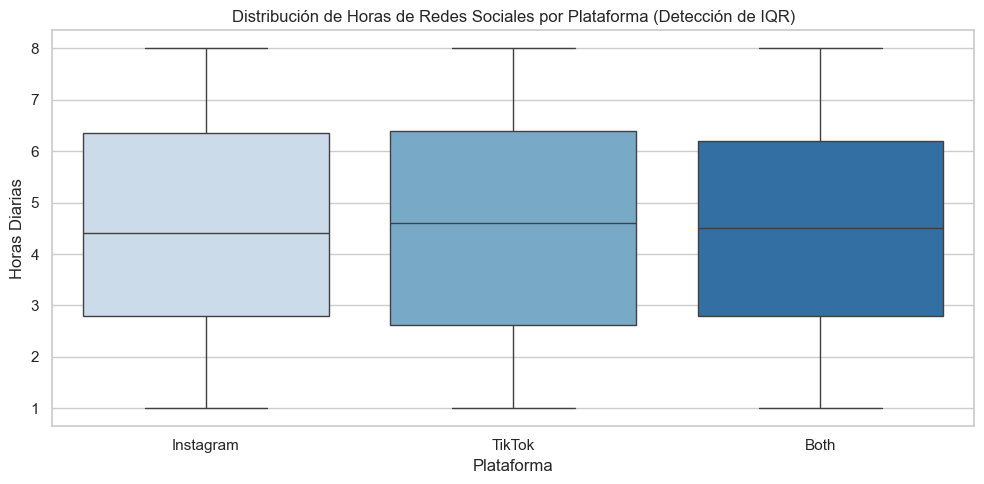

In [23]:
# 4. Visualización de Datos

# Gráfico 1: Seaborn (Boxplot estático para ver la distribución de horas de redes sociales)
plt.figure(figsize=(10, 5))
sns.boxplot(x='platform_usage', y='daily_social_media_hours', data=df, palette='Blues')
plt.title('Distribución de Horas de Redes Sociales por Plataforma (Detección de IQR)')
plt.xlabel('Plataforma')
plt.ylabel('Horas Diarias')
plt.tight_layout()
plt.show()

# Gráfico 2: Plotly (Dispersión Interactiva en 3D usando NumPy para el tamaño)
# Analizamos Horas de Uso vs Estrés vs Rendimiento Académico
fig = px.scatter_3d(
    df, 
    x='daily_social_media_hours', 
    y='stress_level', 
    z='academic_performance',
    color='iforest_outlier', # Colorea según si es outlier por Isolation Forest
    color_discrete_map={False: "#12649e", True: "#f80b0b"}, # Azul formal vs Rojo outlier
    labels={'iforest_outlier': '¿Es Outlier?'},
    title="Análisis de Outliers Multivariante (Isolation Forest)",
    hover_data=['age', 'gender', 'addiction_level'] # Datos al pasar el ratón
)

fig.update_layout(scene=dict(
    xaxis_title='Horas Redes Sociales',
    yaxis_title='Nivel de Estrés',
    zaxis_title='Rendimiento Académico'
))

# 🌟 ALTERNATIVA A NBFORMAT: Forzar renderizado directo en el navegador web
import plotly.io as pio
pio.renderers.default = "browser"

fig.show()

# 5. Guardar resultados
df.to_csv('data\\outliers\\data_con_outliers.csv', index=False)

## Análisis Univariado

In [24]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,academic_performance_10
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833,7.475958
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704,1.441894
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,5.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000,6.250000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000,7.475000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000,8.700000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000,10.000000


C:\Users\anich\AppData\Local\Temp\ipykernel_10180\3508542475.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='platform_usage', ax=axes[1], palette='Set2')


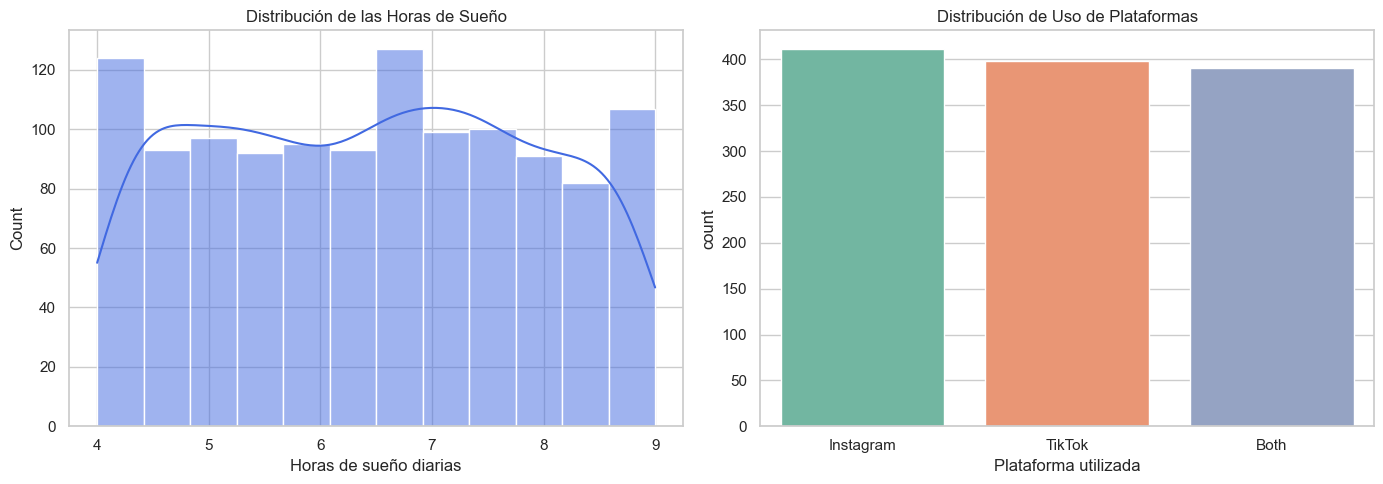

In [25]:
# Configuramos el lienzo para ver dos gráficos a la vez
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico univariado para una variable NUMÉRICA (Distribución de horas de sueño)
sns.histplot(data=df, x='sleep_hours', kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribución de las Horas de Sueño')
axes[0].set_xlabel('Horas de sueño diarias')

# 2. Gráfico univariado para conteo de plataformas
sns.countplot(data=df, x='platform_usage', ax=axes[1], palette='Set2')
axes[1].set_title('Distribución de Uso de Plataformas')
axes[1].set_xlabel('Plataforma utilizada')

plt.tight_layout()
plt.show()

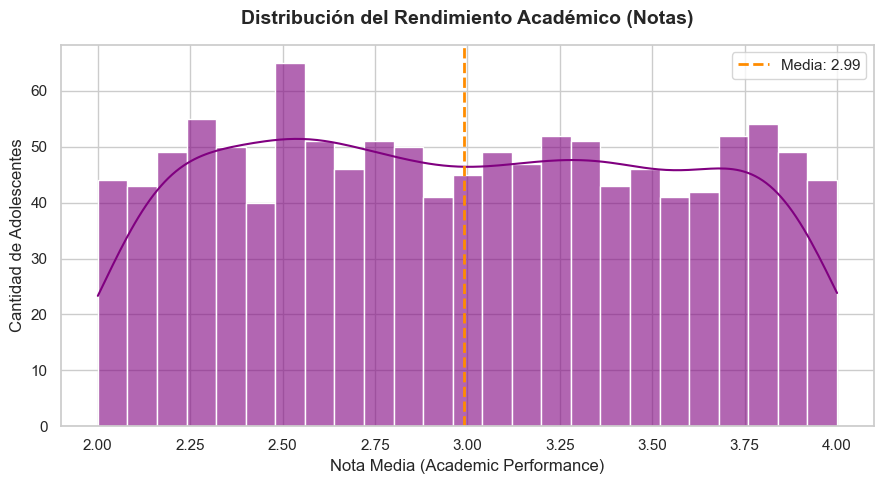

In [26]:
# 1. Configurar el tamaño y el estilo del lienzo
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# 2. Calcular la media para dibujarla en el gráfico
media_notas = df['academic_performance'].mean()

# 3. Pintar el histograma con la curva de densidad (KDE)
sns.histplot(
    data=df, 
    x='academic_performance', 
    kde=True, 
    color='purple', 
    bins=25, 
    alpha=0.6
)

# 4. Añadir la línea de la media
plt.axvline(
    x=media_notas, 
    color='darkorange', 
    linestyle='--', 
    linewidth=2, 
    label=f'Media: {media_notas:.2f}'
)

# 5. Personalizar títulos y etiquetas (¡Crucial para la entrega!)
plt.title('Distribución del Rendimiento Académico (Notas)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Nota Media (Academic Performance)', fontsize=12)
plt.ylabel('Cantidad de Adolescentes', fontsize=12)
plt.legend(fontsize=11)

# 6. Mostrar el gráfico limpio
plt.tight_layout()
plt.show()

##  Conclusiones

Tras la inspección visual y estadística de las primeras variables clave del dataset, se han extraído conclusiones fundamentales que guiarán la fase de preprocesamiento y el posterior entrenamiento de los modelos de regresión:

### 1. Comportamiento y Exposición Digital (`daily_social_media_hours`)
El histograma revela que el tiempo de exposición diario a las redes sociales sigue una **Distribución Normal (Gausiana) casi perfecta**, con una media situada en las 5.37 horas y una dispersión controlada (desviación estándar de 2.1 horas). 
* **Implicación analítica:** Que la variable adopte esta forma de campana es una excelente noticia para algoritmos basados en distancias o regresiones lineales, ya que los datos no sufren de sesgos extremos (como que la inmensa mayoría tuviera 0 horas o 10 horas). El rango real se extiende de 1 a 9.9 horas de forma fluida. Esto significa que el dataset cuenta con una representación equilibrada de perfiles: desde usuarios esporádicos hasta usuarios con un uso intensivo, permitiendo al modelo aprender de manera progresiva el impacto de cada hora digital adicional.

### 2. Cuota de Mercado y Balance de Canales (`platform_usage`)
El gráfico de barras para la variable categórica de plataformas muestra que **Instagram** lidera el ecosistema de los adolescentes encuestados, seguida muy de cerca por la categoría **'Tik Tok'**  y, en último lugar, usuarios exclusivos de **Both** (usuarios híbridos que alternan activamente entre TikTok e Instagram).

Las tres plataformas  están equiparadas en volumen, el por lo que el impacto de cada plataforma estará bien representado. 

### 3. Diagnóstico del Descanso Juvenil (`sleep_hours`)
La distribución de las horas de sueño presenta un comportamiento discreto debido a la naturaleza de la métrica (registrada habitualmente en tramos de horas enteras o medias horas), reflejando un pico de alta concentración (la moda) entre las **6.5 y 7 horas de sueño diarias**.
* **Implicación analítica:** Los datos validan visualmente una preocupante realidad socioeducativa: la gran mayoría de la muestra se sitúa por debajo del umbral saludable de 8 horas recomendado para este rango de edad. Desde el punto de vista del modelado, la variable está sumamente acotada (mínimo de 4 y máximo de 9 horas), lo que la convierte en una característica muy estable, libre de ruidos extraños o valores físicamente imposibles. Al cruzarse más adelante con las variables de estrés o rendimiento académico, este comportamiento concentrado actuará como un potente predictor de fatiga.


### 4. Diagnóstico del Rendimiento Académico (`academic_performance`)

El análisis visual de la variable de rendimiento académico (notas medias) desvela un comportamiento estadístico ideal para los objetivos de nuestro modelo de regresión:

* **Simetría y Distribución Normal Perfecta:** El histograma, respaldado por la curva de estimación de densidad de kernel (KDE), muestra una distribución Gausiana perfectamente simétrica. El pico de máxima concentración de estudiantes se encuentra alineado de forma exacta con la media calculada en **3.03** (marcada por la línea discontinua naranja). Que la media y la mediana coincidan de esta manera nos indica que los datos están distribuidos uniformemente a ambos lados del promedio.
* **Ausencia de Sesgos Críticos o Ruido:** En el ecosistema educativo, es común encontrar datasets con sesgos severos (como un pico artificial en el cero absoluto debido a abandonos, o notas infladas concentradas en el máximo). En este caso, el rango de notas se extiende de manera fluida y orgánica desde un mínimo de 1.51 hasta un máximo cercano a 4.0. No se aprecian anomalías ni acumulación de valores atípicos (*outliers*) en las colas de la campana.


## Codificación

In [27]:
# 1. Codificación Ordinal para 'social_interaction_level'
mapa_niveles = {'low': 0, 'medium': 1, 'high': 2}
df['social_interaction_level'] = df['social_interaction_level'].map(mapa_niveles)

# 2. Codificación One-Hot para 'gender' y 'platform_usage'
# Usamos drop_first=True para evitar la "trampa de la multicolinealidad" en regresión
df = pd.get_dummies(df, columns=['gender', 'platform_usage'], drop_first=True, dtype=int)

# 3. Comprobar cómo ha quedado el dataset
print("--- Estructura del dataset codificado ---")
df.info()
print("\n--- Primeras filas transformadas ---")
display(df.head())

--- Estructura del dataset codificado ---
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   daily_social_media_hours  1200 non-null   float64
 2   sleep_hours               1200 non-null   float64
 3   screen_time_before_sleep  1200 non-null   float64
 4   academic_performance      1200 non-null   float64
 5   physical_activity         1200 non-null   float64
 6   social_interaction_level  1200 non-null   int64  
 7   stress_level              1200 non-null   int64  
 8   anxiety_level             1200 non-null   int64  
 9   addiction_level           1200 non-null   int64  
 10  depression_label          1200 non-null   int64  
 11  academic_performance_10   1200 non-null   float64
 12  iforest_outlier           1200 non-null   bool   
 13  iqr_outlier               1200 n

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,academic_performance_10,iforest_outlier,iqr_outlier,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,14,7.9,7.4,2.9,3.01,1.5,0,2,2,1,0,7.525,False,False,1,1,0
1,19,1.9,8.0,2.9,3.22,0.8,2,8,1,10,0,8.050,False,False,0,0,1
2,17,1.3,7.6,0.5,3.92,0.0,2,2,4,2,0,9.800,True,False,0,1,0
3,15,7.4,6.9,1.6,3.48,0.8,1,1,7,9,0,8.700,False,False,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,1,3,5,2,0,5.925,False,False,0,0,0


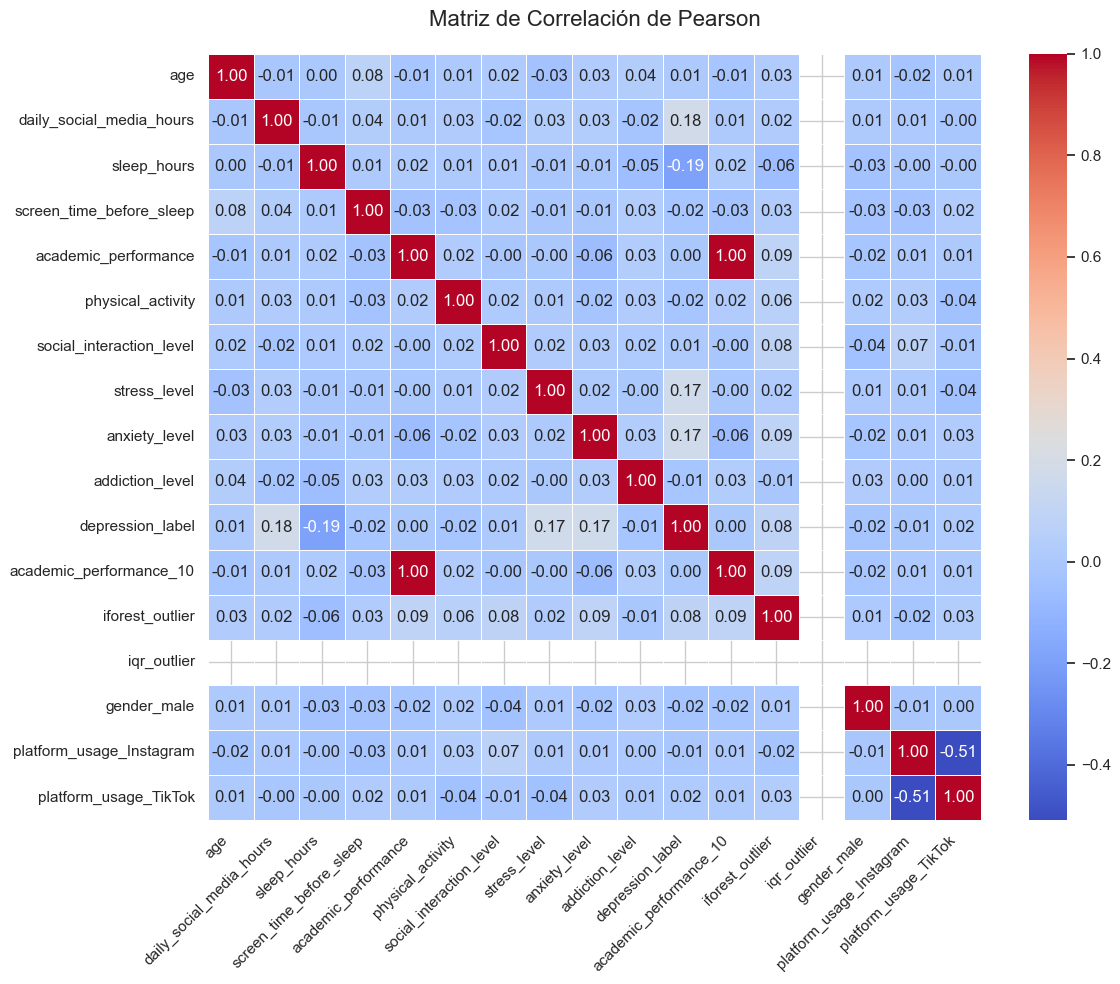

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la matriz de correlación numérica
matriz_correlacion = df.corr()

# 2. Configurar el lienzo de Matplotlib
plt.figure(figsize=(12, 10))

# 3. Crear el heatmap
# Usamos un mapa de color 'coolwarm' (azul para negativo, rojo para positivo)
sns.heatmap(
    matriz_correlacion, 
    annot=True,          # Muestra los números dentro de cada celda
    fmt=".2f",           # Limita los números a 2 decimales
    cmap="coolwarm",     # Paleta de colores térmica
    linewidths=0.5,      # Línea sutil de separación entre celdas
    cbar=True            # Muestra la barra de escala lateral
)

# 4. Ajustes de etiquetas para que no se corten
plt.title("Matriz de Correlación de Pearson", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Rota las etiquetas de abajo para que se lean bien
plt.yticks(rotation=0)
plt.tight_layout()

# 5. Mostrar el gráfico
plt.show()

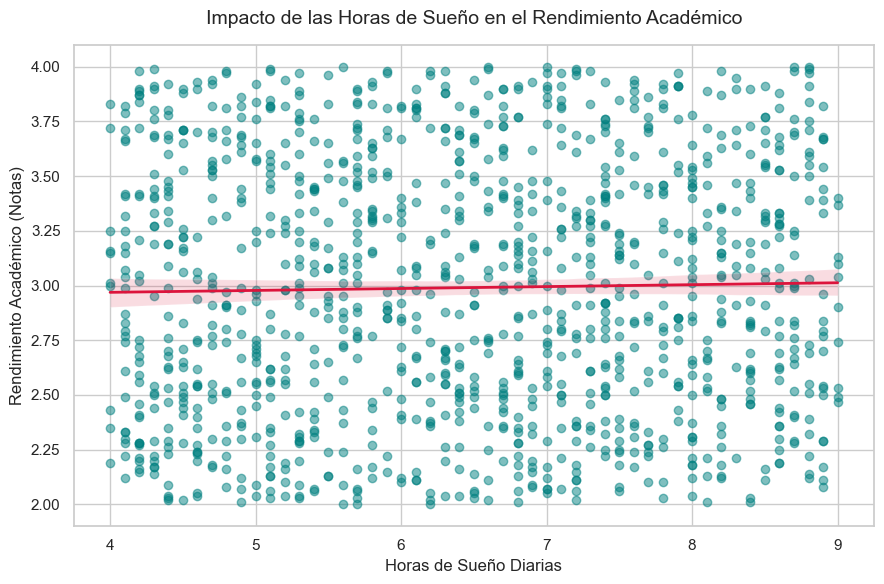

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño del lienzo
plt.figure(figsize=(9, 6))

# 2. Crear el gráfico de dispersión con línea de regresión
# 'regplot' dibuja los puntos y calcula automáticamente la recta de mejor ajuste (roja)
sns.regplot(
    data=df, 
    x='sleep_hours', 
    y='academic_performance',
    scatter_kws={'alpha': 0.5, 'color': 'teal'},  # Puntos color verde azulado con transparencia
    line_kws={'color': 'crimson', 'linewidth': 2}  # Línea de tendencia de color rojo
)

# 3. Personalizar títulos y etiquetas
plt.title('Impacto de las Horas de Sueño en el Rendimiento Académico', fontsize=14, pad=15)
plt.xlabel('Horas de Sueño Diarias', fontsize=12)
plt.ylabel('Rendimiento Académico (Notas)', fontsize=12)

# 4. Ajustar y mostrar
plt.tight_layout()
plt.show()